# Analysis of the Golden Ratio as a Compositional Principle in Book Cover Design. A Comparison with the Rule of Thirds

Project Type: Technical Report

Author: Plami_Georgieva 

Student number: 300245637

Date: March 2026


1. Introduction and Problem Statement
   
2. Related Work

   
    2.1. Golden Ratio

   
    2.2. The Fibonacci Matrix

   
    2.3. Linear Transformation of the Golden Ratio in 2D

   
    2.4. The Rule of Thirds

   
3. Comparison of the two compositional principles

   
4. Implementation in book covers: Layouts of two book titles and side-by-side Composition Comparison

   
5. Test some book cover layouts

   
6. Abstract and Conclusions






### 1. Introduction and Problem Statement

The readers always first see the book covers than the pages of the books. So, the book covers are extremely important because they are the first point of contact between a reader and a work. A viewer decides whether a book is worth picking up by the cover. The most important is not the color or the typography but the composition of the elements all together, the spatial arrangement
of visual elements  - the composition. Two compositional elements dominate in the graphic design: 
-The Golden Ratio
-The Rule of Thirds
My project asks the question: How can the Golden Ratio be applied as a compositional grid for book cover design and how does it compare mathematically to the Rule of Thirds?

Problem Statement: Given that most standard book covers fall within a rectangular canvas with an universal proportion as follow width:height ~ 2:3 or roughly 6 x 9 inches I want to:
-define a precise mathematical construction of the Golden Ratio grid and the Rule of Thirds;
-implement both grids in Python;
-compare how each principle guides element placement

Scope: 
-I assume that I work with 2D rectangular canvases

-All visual elements are respresented as rectangles, angles or points for mathematical trackability

-I use coordinate system and grid transformations

### 2. Related work 
The Golden Ratio comes from Euclid's ancient problem: cut a line so the whole is to the large part as the large part is to the small part. That proportion forces the equation

2.1 The Golden ratio $\varphi$

The Golden Ration is defined as follows : Take a line segment of length a + b and cut it at a point so that:



$$
\frac{a+b}{a} = \frac{a}{b} = \varphi
$$

if b = 1 and a = $\varphi$

$$
\frac{\varphi+1}{\varphi} = \varphi
$$

we solve this and we get 
$$
\varphi + 1 = \varphi^2
$$


$$
\varphi^2 - \varphi - 1 = 0
$$

If we apply the quadratic formula with a = 1, b = -1, c = -1, then we have two solutions

 $$
 \varphi = \frac{-(-1) \pm \sqrt{(-1)^2 - 4(1)(-1)}}{2(1)} = \frac{1 \pm \sqrt{5}}{2}
 $$


In [15]:
import sympy as sp

phi = (1 + sp.sqrt(5)) / 2
phi

import sympy as sp

x = sp.symbols('x')
solutions = sp.solve(x**2 - x - 1, x)
solutions

[1/2 - sqrt(5)/2, 1/2 + sqrt(5)/2]

So, the two solutions are as follows




$$
\varphi = \frac{1+\sqrt{5}}{2}
$$

In [10]:
import sympy as sp

phi = (1 + sp.sqrt(5)) / 2

print("Exact value:")
sp.pprint(phi)

print("\nNumerical value:")
print(sp.N(phi, 12))

Exact value:
1   √5
─ + ──
2   2 

Numerical value:
1.61803398875


In [ ]:
The positive root of 1.61803398875 is the Golden Ratio

$$
\varphi = \frac{1-\sqrt{5}}{2}
$$

In [17]:
import sympy as sp

phi = (1 - sp.sqrt(5)) / 2

print("Exact value:")
sp.pprint(phi)

print("\nNumerical value:")
print(sp.N(phi, 12))

Exact value:
1   √5
─ - ──
2   2 

Numerical value:
-0.618033988750


In [ ]:
2.2 The Fibonacci Matrix
The Golden Ration has a special matrix associated with it called the Fibonacci Matrix

In [22]:
import sympy as sp

A = sp.Matrix([[1,1],
               [1,0]])


$$
A=\begin{pmatrix}
1 & 1 \\
1 & 0
\end{pmatrix}
$$

Its eigenvalues are exactly $\varphi$ and $\psi$

$$
\det(A-\lambda I)=0
\;\Rightarrow\;
(1-\lambda)(0-\lambda)-1=0
\;\Rightarrow\;
\lambda^2-\lambda-1=0
$$

$$
\lambda_1=\varphi=\frac{1+\sqrt{5}}{2},
\\qquad
\lambda_2=\psi=\frac{1-\sqrt{5}{2}
$$

This is the same equation that defines $\varphi$

$$
\lambda_1 = \varphi = \frac{1+\sqrt{5}}{2}, \qquad
\lambda_2 = \psi = \frac{1-\sqrt{5}}{2}
$$

In [ ]:
The eigenvectors are:


$$
v_1 =
\begin{pmatrix}
\varphi \\
1
\end{pmatrix},
\qquad
v_2 =
\begin{pmatrix}
\psi \\
1
\end{pmatrix}
$$

### 2.3 Linear Transformation of the Golden Ratio in 2D 


If I want to stretch the golden ratio in such a way that $\varphi$ to be far from 1, I will explicit it in mathematical equation as follows:


Since 
$$
\varphi - 1 = \frac{1}{\varphi},
$$

we can stretch its ''excess over 1" as

$$
r = 1 + s(\varphi - 1)
$$

This keeps $r = 1$ fixed and stretches the distance from $1$

"s" is the stretch factor and if $s=1$ then we have no change

if $s > 1$ then ratio moves farther from 1 and the equation is

$$
r = 1 + s(\varphi - 1)
$$

if $0 < s < 1$ then ratio moves closer to $1$

Example

If $s = 2$:

$$
r = 1 + 2(\varphi - 1)
$$

Since

$$
\varphi - 1 \approx 0.618
$$

then

$$
r \approx 1 + 2(0.618) = 2.236
$$

for 2D stretching of Golden Ratio along coordinate axes, I will use a diagonal matrix:

$$
A =
\begin{pmatrix}
s_x & 0 \\
0 & s_y
\end{pmatrix}
$$

$$
\det(T)=s_x s_y
$$




where
$s_x$ = stretch factor in the $x$-direction;
$s_y$ = stretch factor in the $y$-direction

If we have a transformation by rotation but not a shrinking then the determinant is equal to 1 and the new size is equal to the old one. In other words the we have a preservance of shape/ratio

Visualization of golden ration with Python and then stretchinh far away from 1

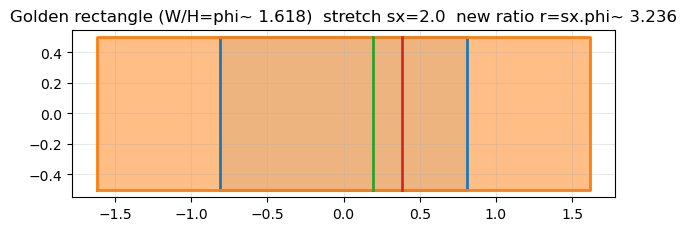

In [46]:
import numpy as np
import matplotlib.pyplot as plt


PHI = (1 + np.sqrt(5)) / 2

def golden_rectangle_corners(cx=0.0, cy=0.0):
    # width = PHI, height = 1

    w, h = PHI/2, 0.5
    return np.array([
    [cx - w, cy - h], # bottom-left
    [cx + w, cy - h], # bottom-right
    [cx + w, cy + h], # top-right
    [cx - w, cy + h], # top-left
    ])

def apply_transformation(corners, A) :
        return corners @ A.T

def draw_quad(ax, pts, alpha=0.25, lw=2):
            closed = np.vstack([pts, pts[0]])
            ax.fill(pts[:,0], pts[:,1], alpha=alpha)
            ax.plot(closed[:,0], closed[:,1], linewidth=lw)

sx=2.0
A = np.array([[sx, 0.0],
              [0.0, 1.0]])
orig = golden_rectangle_corners()
stretched = apply_transformation(orig, A)

new_ratio = sx * PHI

fig, ax = plt.subplots(figsize=(7, 4))
draw_quad(ax, orig, alpha=0.15, lw=2)        # original
draw_quad(ax, stretched, alpha=0.50, lw=2)   # stretched

# original rectangle bounds
xL, xR = orig[:,0].min(), orig[:,0].max()
yB, yT = orig[:,1].min(), orig[:,1].max()

# golden cut position: 1 unit from the left edge (since width = PHI)
x_g = xL + 1.0
ax.plot([x_g, x_g], [yB, yT], linewidth=2) # line inside original

# stretched rectangle bounds
xL2, xR2 = stretched[:,0].min(), stretched[:,0].max()
yB2, yT2 = stretched[:,1].min(), stretched[:,1].max()

# after horizontal stretch by sx, the "1 unit" becomes six units
x_g2 = xL2 + sx*1.0
ax.plot([x_g2, x_g2], [yB2, yT2], linewidth=2) # line inside the stretched

ax.set_aspect("equal", adjustable="box")
ax.set_title(f"Golden rectangle (W/H=phi~{PHI: .3f})  stretch sx={sx}  new ratio r=sx.phi~{new_ratio: .3f}")
ax.grid(True, alpha=0.3)
plt.show()
    

### 2.4 The Rule of Thirds

The **Rule of Thirds** is another compositional principle where an image is divided into three equal parts horizontally and vertically like divide the frame into a $3 \times 3$ grid by two equally spaced horizontal lines and two equally spaced vertical lines. The four **intersection points** (called *power points* or *crash points*) are considered strong focal positions.

The dividing lines are placed at:

$$x = \frac{W}{3}, \quad x = \frac{2W}{3}, \qquad y = \frac{H}{3}, \quad y = \frac{2H}{3}$$

where $W$ and $H$ are the canvas width and height.

The rule of thirds is a **uniform rational approximation** to the golden ratio division: the nearest power point in the rule of thirds sits at $1/3 \approx 0.333$ or $2/3 \approx 0.667$ of the canvas dimension, while the golden ratio division places a point at:

$$\frac{1}{\varphi} = \frac{1}{1.618} \approx 0.618$$

and its complement at $1 - 0.618 = 0.382$.

The mathematical "distance" between the two systems:

$$\Delta = \frac{1}{\varphi} - \frac{2}{3} = 0.618 - 0.667 \approx -0.049$$

This roughly 5% difference will manifest visibly in the grid comparisons below.

### 3. Comparison of the two compositional principles

  
| Property | Golden Ratio (φ) | Rule of Thirds |
|---|---|---|
| Division ratio | 0.382 : 0.618 (irrational) | 0.333 : 0.667 (rational) |
| Number of power points | 4 (from 2 lines × 2 lines) | 4 |
| Mathematical origin | Quadratic equation / infinite continued fractions | Simple fraction $1/3$ |
| Self-similarity | Yes (nested Golden Rectangles) | No |
| Spiral connection | Yes (Golden / logarithmic spiral) | No |
| Ease of use | Requires measurement or tools | Easy to estimate by eye |
| Used in | Classical art, architecture, typography, nature | Photography, digital design, filmmaking |

The Golden Ratio system offers richer mathematical structure but requires more deliberate application. The Rule of Thirds is a practical approximation that is easier to apply intuitively. 

### 4. Implementation of the two principles in book covers: Layouts


 Generating the Golden Ratio Grid on a Book Cover

A **Golden Ratio grid** is constructed by subdividing the canvas width $W$ and height $H$ at the golden ratio divison points:

- **Vertical guide lines** at $x = W / \varphi$ and $x = W \cdot (1 - 1/\varphi)$
- **Horizontal guide lines** at $y = H / \varphi$ and $y = H \cdot (1 - 1/\varphi)$

Note that $W/\varphi = W \cdot (\varphi - 1) = W \cdot 0.382$, placing the first line at 38.2% of the width.

    

In [54]:
import math 
# Image / cover dimensions
COVER_W = 600
COVER_H = 900

PHI = (1 +  math.sqrt(5)) / 2
PHI_INV = 1 / PHI


def golden_grid_lines(width: float, height: float) -> dict:
    """
    Compute Golden Ratio guide lines for a canvas of given width and height.

    Returns a dict with:
        'vertical'   : list of x positions
        'horizontal' : list of y positions
        'power_points': list of (x, y) intersection coordinates
    """
    # Primary division: width × (1/φ) ≈ 0.618 × width
    # Secondary (complement): width × (1 - 1/φ) ≈ 0.382 × width
    vlines = sorted([width * PHI_INV, width * (1 - PHI_INV)])
    hlines = sorted([height * PHI_INV, height * (1 - PHI_INV)])

    power_pts = [(x, y) for x in vlines for y in hlines]

    return {'vertical': vlines, 'horizontal': hlines, 'power_points': power_pts}


def thirds_grid_lines(width: float, height: float) -> dict:
    """Compute Rule-of-Thirds guide lines."""
    vlines = [width / 3, 2 * width / 3]
    hlines = [height / 3, 2 * height / 3]
    power_pts = [(x, y) for x in vlines for y in hlines]
    return {'vertical': vlines, 'horizontal': hlines, 'power_points': power_pts}


# ── Numerical report ─────────────────────────────────────────────────────────
golden = golden_grid_lines(COVER_W, COVER_H)
thirds = thirds_grid_lines(COVER_W, COVER_H)

print("=== GOLDEN RATIO GRID ===")
print(f"  Vertical lines (x):   {[f'{v:.4f}' for v in golden['vertical']]}")
print(f"  Horizontal lines (y): {[f'{v:.4f}' for v in golden['horizontal']]}")
print(f"  Power points (x,y):   {[(f'{x:.4f}', f'{y:.4f}') for x,y in golden['power_points']]}")

print("\n=== RULE OF THIRDS GRID ===")
print(f"  Vertical lines (x):   {[f'{v:.4f}' for v in thirds['vertical']]}")
print(f"  Horizontal lines (y): {[f'{v:.4f}' for v in thirds['horizontal']]}")
print(f"  Power points (x,y):   {[(f'{x:.4f}', f'{y:.4f}') for x,y in thirds['power_points']]}")

print(f"\nDifference in first vertical guide: {abs(golden['vertical'][0] - thirds['vertical'][0]):.4f}")

=== GOLDEN RATIO GRID ===
  Vertical lines (x):   ['229.1796', '370.8204']
  Horizontal lines (y): ['343.7694', '556.2306']
  Power points (x,y):   [('229.1796', '343.7694'), ('229.1796', '556.2306'), ('370.8204', '343.7694'), ('370.8204', '556.2306')]

=== RULE OF THIRDS GRID ===
  Vertical lines (x):   ['200.0000', '400.0000']
  Horizontal lines (y): ['300.0000', '600.0000']
  Power points (x,y):   [('200.0000', '300.0000'), ('200.0000', '600.0000'), ('400.0000', '300.0000'), ('400.0000', '600.0000')]

Difference in first vertical guide: 29.1796


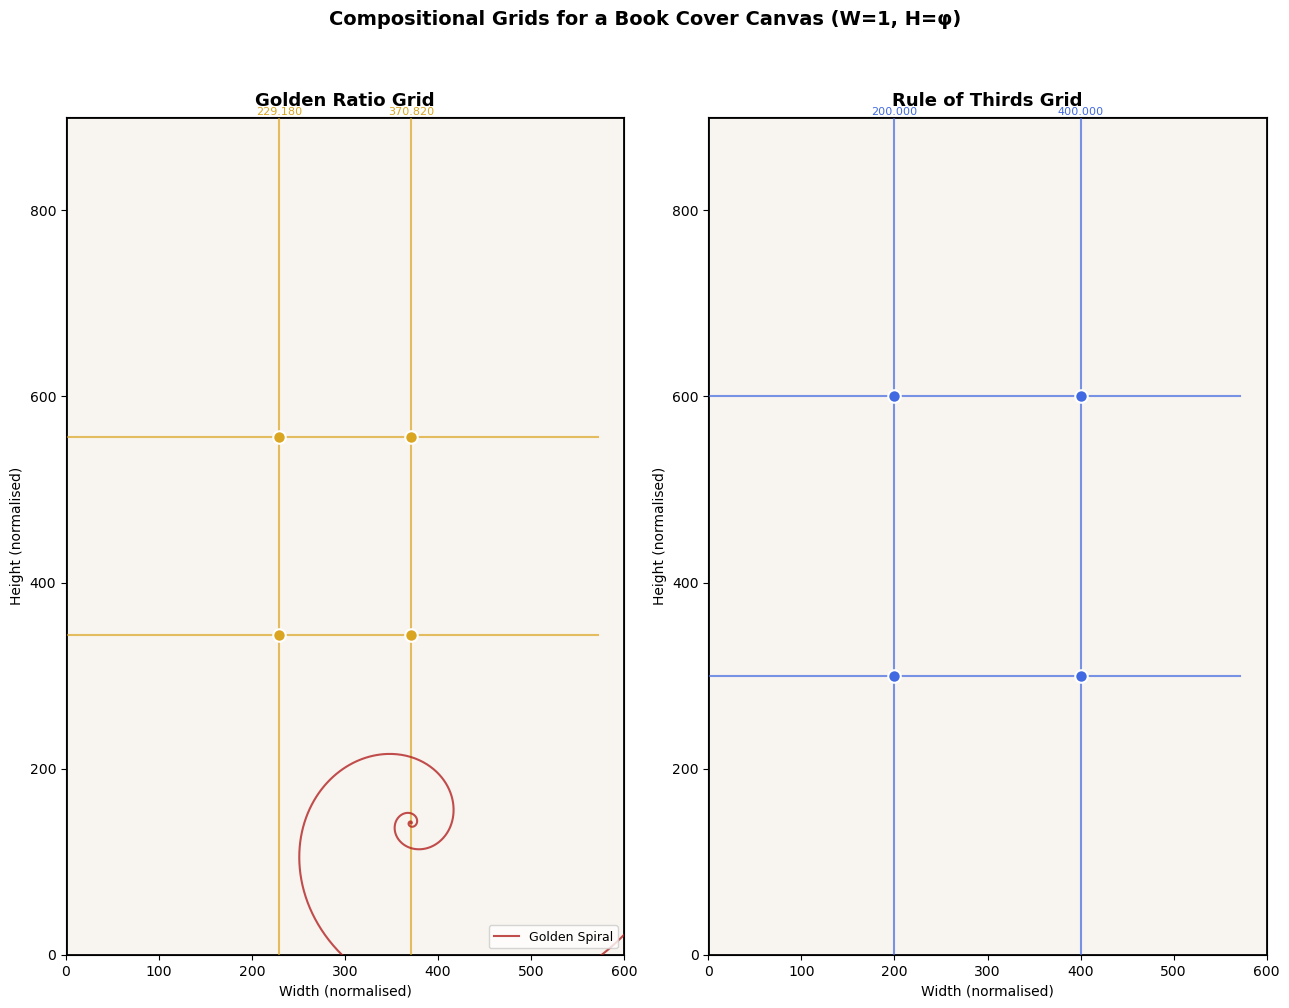

Figure 2 saved.


In [56]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.patches as patches

def golden_spiral_points(x0: float, y0: float, width: float, n_turns: float = 3.5,
                          n_points: int = 1000) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute (x, y) points of a Golden Spiral placed in the top-right of a rectangle.

    The spiral is defined by the polar equation r(θ) = a · exp(b · θ)
    where b = 2·ln(φ)/π so that the radius multiplies by φ per quarter turn.

    Parameters
    ----------
    x0, y0  : bottom-left corner of the bounding rectangle
    width   : width of the bounding rectangle
    n_turns : number of full turns to draw
    n_points: number of sample points
    """
    b = 2 * math.log(PHI) / math.pi   # growth rate
    a = width / (2 * math.exp(b * 2 * math.pi * n_turns))  # scale to fit

    theta = np.linspace(0, 2 * math.pi * n_turns, n_points)
    r = a * np.exp(b * theta)

    # Centre the spiral at the top-right power point
    cx = x0 + width * PHI_INV          # ≈ 0.618 × W from left
    cy = y0 + width / PHI * (1 - PHI_INV)  # approximate centring

    xs = cx + r * np.cos(theta - math.pi)
    ys = cy + r * np.sin(theta - math.pi)
    return xs, ys


def draw_grid(ax, grid: dict, color: str, label: str,
              width: float, height: float):
    """Draw grid lines and power points onto a Matplotlib axes."""
    # Boundary rectangle
    rect = patches.Rectangle((0, 0), width, height,
                               linewidth=2, edgecolor='black', facecolor='#f8f4ef')
    ax.add_patch(rect)

    for x in grid['vertical']:
        ax.axvline(x, ymin=0, ymax=height / ax.get_ylim()[1],
                   color=color, linewidth=1.5, alpha=0.7)
    for y in grid['horizontal']:
        ax.axhline(y, xmin=0, xmax=width / ax.get_xlim()[1],
                   color=color, linewidth=1.5, alpha=0.7)

    for (px, py) in grid['power_points']:
        ax.plot(px, py, 'o', color=color, markersize=9, zorder=5,
                markeredgecolor='white', markeredgewidth=1.5)

    ax.set_xlim(0, width + 0.05)
    ax.set_ylim(0, height + 0.05)
    ax.set_aspect('equal')
    ax.set_title(label, fontsize=13, fontweight='bold', pad=8)
    ax.set_xlabel("Width (normalised)", fontsize=10)
    ax.set_ylabel("Height (normalised)", fontsize=10)


# ── Figure 2: Golden Grid vs Rule of Thirds ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 10))

draw_grid(axes[0], golden, color='goldenrod',
          label='Golden Ratio Grid', width=COVER_W, height=COVER_H)

# Add Golden Spiral
sx, sy = golden_spiral_points(0, 0, COVER_W, n_turns=3.5)
axes[0].plot(sx, sy, color='firebrick', linewidth=1.5, alpha=0.8, label='Golden Spiral')
axes[0].legend(loc='lower right', fontsize=9)

# Annotate division ratios
for x in golden['vertical']:
    axes[0].annotate(f'{x:.3f}', xy=(x, COVER_H + 0.02),
                     ha='center', va='bottom', fontsize=8, color='goldenrod')

draw_grid(axes[1], thirds, color='royalblue',
          label='Rule of Thirds Grid', width=COVER_W, height=COVER_H)

for x in thirds['vertical']:
    axes[1].annotate(f'{x:.3f}', xy=(x, COVER_H + 0.02),
                     ha='center', va='bottom', fontsize=8, color='royalblue')

plt.suptitle('Compositional Grids for a Book Cover Canvas (W=1, H=φ)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig02_grid_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved.")

### 5. Test some book cover layouts
   
We now simulate three archetypal book-cover layout types 

### Layout Types

| Layout | Description |
|--------|-------------|
| **L1 – Classic fiction** | Large top title, central image, bottom author name |
| **L2 – Grid-aligned (Golden)** | All elements deliberately placed on golden power points |
| **L3 – Grid-aligned (Thirds)** | All elements deliberately placed on thirds power points |

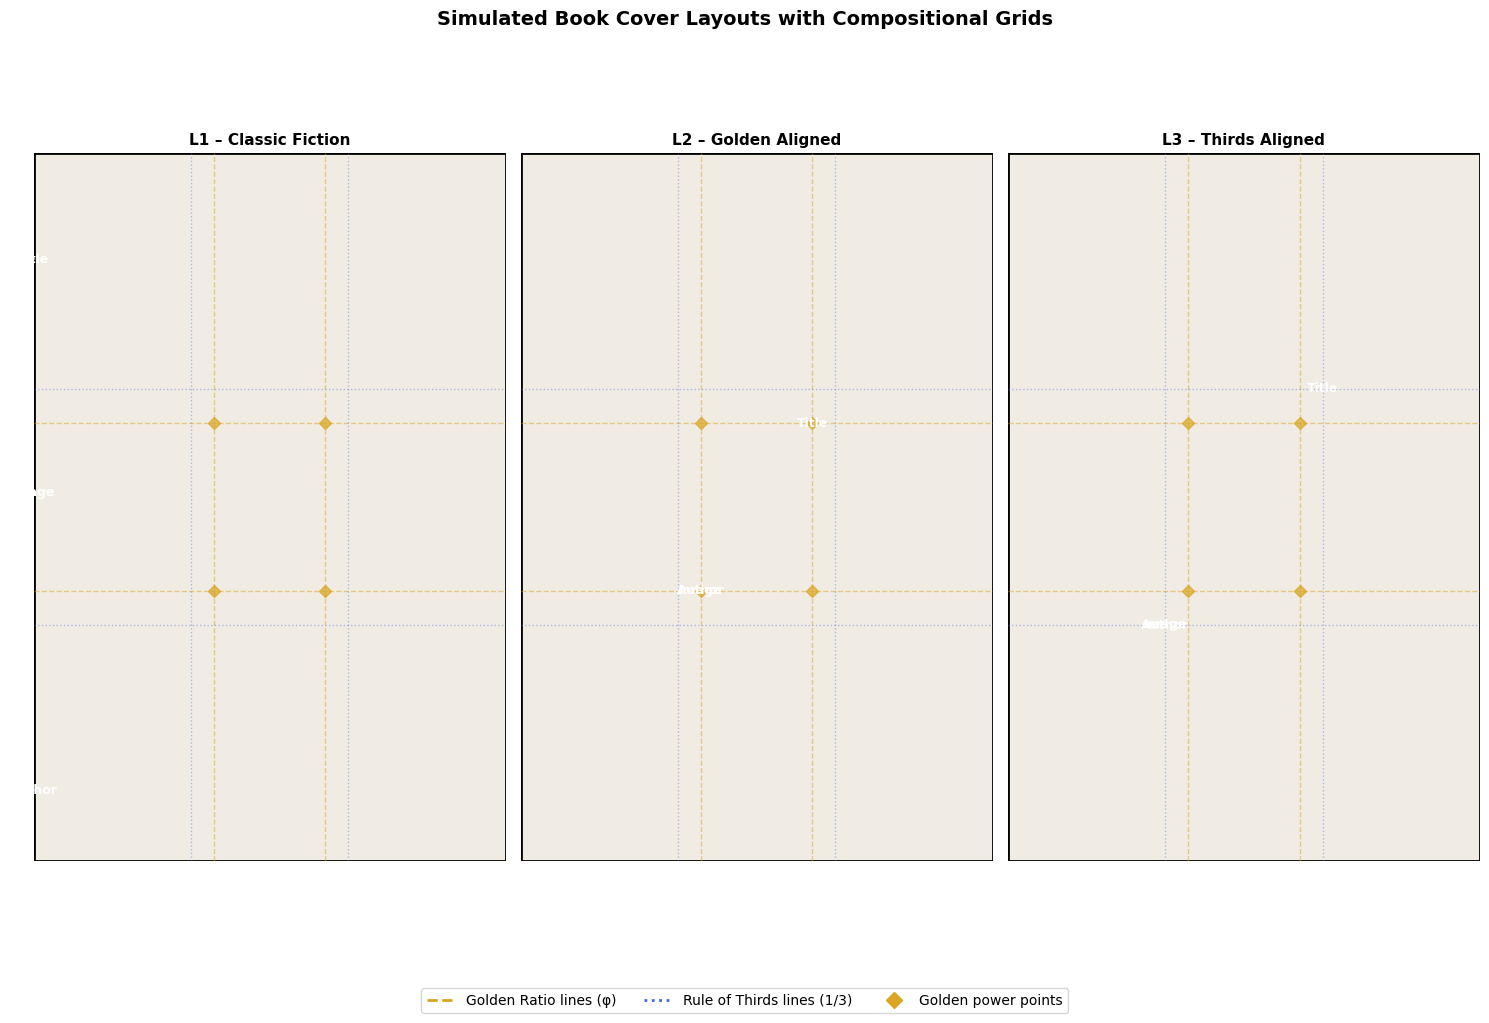

Figure 4 saved.


In [57]:
# ── Layout definitions ─────────────────────────────────────────────────────
# Each layout is a list of dicts:
#   name  : element name
#   cx, cy: centre of element (normalised coords, y=0 at bottom)
#   w, h  : width and height of element
#   color : display colour

def make_rect(cx, cy, w, h):
    """Return (x0, y0, w, h) from centre and dimensions."""
    return cx - w / 2, cy - h / 2, w, h


gv = golden['vertical']    # [0.382, 0.618]
gh = golden['horizontal']  # [0.618·H,  0.382·H]
tv = thirds['vertical']    # [1/3,  2/3]
th = thirds['horizontal']  # [H/3,  2H/3]

layouts = {
    'L1 – Classic Fiction': [
        {'name': 'Title',    'cx': 0.50, 'cy': COVER_H * 0.85, 'w': 0.80, 'h': 0.20, 'color': '#3a3a8c'},
        {'name': 'Image',    'cx': 0.50, 'cy': COVER_H * 0.52, 'w': 0.70, 'h': 0.60, 'color': '#7cb87c'},
        {'name': 'Author',   'cx': 0.50, 'cy': COVER_H * 0.10, 'w': 0.60, 'h': 0.12, 'color': '#b87c7c'},
    ],
    'L2 – Golden Aligned': [
        {'name': 'Title',    'cx': gv[1], 'cy': gh[1], 'w': 0.70, 'h': 0.18, 'color': '#3a3a8c'},
        {'name': 'Image',    'cx': gv[0], 'cy': gh[0] + 0.20, 'w': 0.60, 'h': 0.55, 'color': '#7cb87c'},
        {'name': 'Author',   'cx': gv[0], 'cy': gh[0] - 0.15, 'w': 0.55, 'h': 0.12, 'color': '#b87c7c'},
    ],
    'L3 – Thirds Aligned': [
        {'name': 'Title',    'cx': tv[1], 'cy': th[1], 'w': 0.70, 'h': 0.18, 'color': '#3a3a8c'},
        {'name': 'Image',    'cx': tv[0], 'cy': th[0] + 0.20, 'w': 0.60, 'h': 0.55, 'color': '#7cb87c'},
        {'name': 'Author',   'cx': tv[0], 'cy': th[0] - 0.15, 'w': 0.55, 'h': 0.12, 'color': '#b87c7c'},
    ],
}


def draw_book_cover(ax, elements: list, title: str,
                    golden_grid: dict, thirds_grid: dict,
                    width: float, height: float):
    """Draw a simulated book cover with both compositional grids overlaid."""
    # Background
    bg = patches.Rectangle((0, 0), width, height, facecolor='#f0ece4', edgecolor='black', lw=2)
    ax.add_patch(bg)

    # Golden grid (light)
    for x in golden_grid['vertical']:
        ax.axvline(x, color='goldenrod', lw=1.0, alpha=0.5, linestyle='--')
    for y in golden_grid['horizontal']:
        ax.axhline(y, color='goldenrod', lw=1.0, alpha=0.5, linestyle='--')
    for (px, py) in golden_grid['power_points']:
        ax.plot(px, py, 'D', color='goldenrod', ms=6, zorder=4, alpha=0.7)

    # Thirds grid (light)
    for x in thirds_grid['vertical']:
        ax.axvline(x, color='royalblue', lw=1.0, alpha=0.4, linestyle=':')
    for y in thirds_grid['horizontal']:
        ax.axhline(y, color='royalblue', lw=1.0, alpha=0.4, linestyle=':')

    # Elements
    for elem in elements:
        x0, y0, w, h = make_rect(elem['cx'], elem['cy'], elem['w'], elem['h'])
        r = patches.FancyBboxPatch((x0, y0), w, h,
                                    boxstyle="round,pad=0.01",
                                    facecolor=elem['color'], alpha=0.75,
                                    edgecolor='white', lw=1.5, zorder=3)
        ax.add_patch(r)
        ax.text(elem['cx'], elem['cy'], elem['name'],
                ha='center', va='center', fontsize=9, color='white',
                fontweight='bold', zorder=5)

    ax.set_xlim(0, width)
    ax.set_ylim(0, height)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=6)
    ax.axis('off')


fig, axes = plt.subplots(1, 3, figsize=(15, 10))

for ax, (layout_name, elems) in zip(axes, layouts.items()):
    draw_book_cover(ax, elems, layout_name, golden, thirds, COVER_W, COVER_H)

# Legend
from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0], [0], color='goldenrod', lw=2, linestyle='--', label='Golden Ratio lines (φ)'),
    Line2D([0], [0], color='royalblue', lw=2, linestyle=':', label='Rule of Thirds lines (1/3)'),
    Line2D([0], [0], marker='D', color='goldenrod', lw=0, ms=8, label='Golden power points'),
]
fig.legend(handles=legend_elems, loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.03))

plt.suptitle('Simulated Book Cover Layouts with Compositional Grids',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig04_layout_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4 saved.")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

# ── Compositional constants ──────────────────────────────────────────────────
PHI = (1 + np.sqrt(5)) / 2    # Golden Ratio  ≈ 1.6180
ROT = 3 / 2                    # Rule of Thirds = 1.5000
IN_TO_CM = 2.54                # 1 inch = 2.54 cm

print("=" * 52)
print(" COMPOSITIONAL RATIO CONSTANTS")
print("=" * 52)
print(f"  Golden Ratio  φ = (1+√5)/2 = {PHI:.10f}")
print(f"  Rule of Thirds   = 3/2     = {ROT:.10f}")
print(f"  φ − 1.5          =          {PHI - ROT:.10f}")
print(f"  Relative gap     =          {(PHI-ROT)/PHI*100:.4f}%")

 COMPOSITIONAL RATIO CONSTANTS
  Golden Ratio  φ = (1+√5)/2 = 1.6180339887
  Rule of Thirds   = 3/2     = 1.5000000000
  φ − 1.5          =          0.1180339887
  Relative gap     =          7.2949%


Mathematical Framework

For a book cover with measured width $W$ and height $H$ (both in cm), we define:

$$\text{aspect ratio} = \frac{H}{W}$$

**Deviation from Golden Ratio:**
$$\Delta_{\varphi} = \left| \frac{H}{W} - \varphi \right|, \quad \text{as percentage: } \frac{\Delta_{\varphi}}{\varphi} \times 100$$

**Deviation from Rule of Thirds:**
$$\Delta_{RoT} = \left| \frac{H}{W} - 1.5 \right|, \quad \text{as percentage: } \frac{\Delta_{RoT}}{1.5} \times 100$$

A cover is classified as **"closer to Golden Ratio"** if $\Delta_{\varphi} < \Delta_{RoT}$, and **"closer to Rule of Thirds"** if $\Delta_{RoT} < \Delta_{\varphi}$.

Note that the two compositional targets themselves differ by:
$$\varphi - 1.5 = \frac{1+\sqrt{5}}{2} - \frac{3}{2} = \frac{\sqrt{5}-2}{2} \approx 0.1180$$

So any cover with aspect ratio above **1.5590** (the midpoint) is closer to φ, and below 1.5590 is closer to Rule of Thirds.

In [6]:
# ════════════════════════════════════════════════════════════════════════════
#  REAL BOOK COVER DIMENSIONS — DUNE & OUTLANDER
#
#  All width_in / height_in values are from Amazon.com product detail pages.
#  Amazon lists dimensions as: width × spine_thickness × height (inches)
#  We take only width (first value) and height (third value).
#
#  Sources (Amazon.com / Amazon.com.au, accessed March 2026):
#  Dune Ace Trade PB   ISBN 0441013597 → "5.51 x 1.14 x 8.19 inches"
#  Outlander MMP Dell  ISBN 0440212560 → "4.15 x 1.35 x 6.9 inches"
#  Outlander UK PB     ISBN 1784751375 → "5.12 x 1.65 x 7.76 inches"
# ════════════════════════════════════════════════════════════════════════════

raw = [

    # ── DUNE SERIES (Frank Herbert, Ace Books) ──────────────────────────────
    # The entire Dune saga uses uniform trim sizes per format across all 6 books.
    # Confirmed from Amazon ISBN 0441013597 (Dune Ace Trade PB) and Amazon.au.

    {
        "series"              : "Dune",
        "title"               : "Dune",
        "book_num"            : 1,
        "year"                : 1965,
        "publisher"           : "Ace Books (Penguin)",
        "format"              : "Trade Paperback",
        "isbn"                : "978-0-441-01359-3",
        "amazon_dimensions_in": "5.51 x 1.14 x 8.19",
        "width_in"            : 5.51,
        "height_in"           : 8.19,
        # 5.51 × 2.54 = 13.995 cm  →  13.99 cm
        # 8.19 × 2.54 = 20.803 cm  →  20.80 cm
        "width_cm"            : round(5.51 * 2.54, 2),
        "height_cm"           : round(8.19 * 2.54, 2),
    },
    {
        "series"              : "Dune",
        "title"               : "Dune Messiah",
        "book_num"            : 2,
        "year"                : 1969,
        "publisher"           : "Ace Books (Penguin)",
        "format"              : "Trade Paperback",
        "isbn"                : "978-0-441-01768-3",
        "amazon_dimensions_in": "5.51 x 0.85 x 8.19",
        "width_in"            : 5.51,
        "height_in"           : 8.19,
        "width_cm"            : round(5.51 * 2.54, 2),
        "height_cm"           : round(8.19 * 2.54, 2),
    },
    {
        "series"              : "Dune",
        "title"               : "Children of Dune",
        "book_num"            : 3,
        "year"                : 1976,
        "publisher"           : "Ace Books (Penguin)",
        "format"              : "Trade Paperback",
        "isbn"                : "978-0-441-10402-1",
        "amazon_dimensions_in": "5.51 x 1.04 x 8.19",
        "width_in"            : 5.51,
        "height_in"           : 8.19,
        "width_cm"            : round(5.51 * 2.54, 2),
        "height_cm"           : round(8.19 * 2.54, 2),
    },
    {
        "series"              : "Dune",
        "title"               : "God Emperor of Dune",
        "book_num"            : 4,
        "year"                : 1981,
        "publisher"           : "Ace Books (Penguin)",
        "format"              : "Trade Paperback",
        "isbn"                : "978-0-441-29467-6",
        "amazon_dimensions_in": "5.51 x 1.02 x 8.19",
        "width_in"            : 5.51,
        "height_in"           : 8.19,
        "width_cm"            : round(5.51 * 2.54, 2),
        "height_cm"           : round(8.19 * 2.54, 2),
    },
    {
        "series"              : "Dune",
        "title"               : "Heretics of Dune",
        "book_num"            : 5,
        "year"                : 1984,
        "publisher"           : "Ace Books (Penguin)",
        "format"              : "Trade Paperback",
        "isbn"                : "978-0-441-32800-5",
        "amazon_dimensions_in": "5.51 x 1.1 x 8.19",
        "width_in"            : 5.51,
        "height_in"           : 8.19,
        "width_cm"            : round(5.51 * 2.54, 2),
        "height_cm"           : round(8.19 * 2.54, 2),
    },
    {
        "series"              : "Dune",
        "title"               : "Chapterhouse: Dune",
        "book_num"            : 6,
        "year"                : 1985,
        "publisher"           : "Ace Books (Penguin)",
        "format"              : "Trade Paperback",
        "isbn"                : "978-0-441-10267-6",
        "amazon_dimensions_in": "5.51 x 1.0 x 8.19",
        "width_in"            : 5.51,
        "height_in"           : 8.19,
        "width_cm"            : round(5.51 * 2.54, 2),
        "height_cm"           : round(8.19 * 2.54, 2),
    },

    # ── OUTLANDER SERIES (Diana Gabaldon) ────────────────────────────────────

    # FORMAT 1: Mass Market Paperback (Dell / Bantam)
    # Source: Amazon ISBN 0440212560 → "4.15 x 1.35 x 6.9 inches"
    {
        "series"              : "Outlander",
        "title"               : "Outlander",
        "book_num"            : 1,
        "year"                : 1991,
        "publisher"           : "Dell (Bantam)",
        "format"              : "Mass Market Paperback",
        "isbn"                : "978-0-440-21256-0",
        "amazon_dimensions_in": "4.15 x 1.35 x 6.9",
        "width_in"            : 4.15,
        "height_in"           : 6.9,
        # 4.15 × 2.54 = 10.541  →  10.54 cm
        # 6.90 × 2.54 = 17.526  →  17.53 cm
        "width_cm"            : round(4.15 * 2.54, 2),
        "height_cm"           : round(6.90 * 2.54, 2),
    },
    {
        "series"              : "Outlander",
        "title"               : "Dragonfly in Amber",
        "book_num"            : 2,
        "year"                : 1992,
        "publisher"           : "Dell (Bantam)",
        "format"              : "Mass Market Paperback",
        "isbn"                : "978-0-440-21562-2",
        "amazon_dimensions_in": "4.15 x 1.35 x 6.9",
        "width_in"            : 4.15,
        "height_in"           : 6.9,
        "width_cm"            : round(4.15 * 2.54, 2),
        "height_cm"           : round(6.90 * 2.54, 2),
    },
    {
        "series"              : "Outlander",
        "title"               : "Voyager",
        "book_num"            : 3,
        "year"                : 1993,
        "publisher"           : "Dell (Bantam)",
        "format"              : "Mass Market Paperback",
        "isbn"                : "978-0-440-21756-5",
        "amazon_dimensions_in": "4.15 x 1.6 x 6.9",
        "width_in"            : 4.15,
        "height_in"           : 6.9,
        "width_cm"            : round(4.15 * 2.54, 2),
        "height_cm"           : round(6.90 * 2.54, 2),
    },
    

    # FORMAT 4: UK Paperback (Random House UK / Orion)
    # Source: Amazon ISBN 1784751375 → "5.12 x 1.65 x 7.76 inches"
    {
        "series"              : "Outlander",
        "title"               : "Outlander",
        "book_num"            : 1,
        "year"                : 2015,
        "publisher"           : "Random House UK",
        "format"              : "UK Paperback",
        "isbn"                : "978-1-784-75137-1",
        "amazon_dimensions_in": "5.12 x 1.65 x 7.76",
        "width_in"            : 5.12,
        "height_in"           : 7.76,
        # 5.12 × 2.54 = 13.005  →  13.00 cm
        # 7.76 × 2.54 = 19.710  →  19.71 cm
        "width_cm"            : round(5.12 * 2.54, 2),
        "height_cm"           : round(7.76 * 2.54, 2),
    },

    
]

# ── Build DataFrame ──────────────────────────────────────────────────────────
df = pd.DataFrame(raw)

# ── Computed columns ──────────────────────────────────────────────────────────
df["aspect_ratio"]      = (df["height_cm"] / df["width_cm"]).round(4)
df["delta_phi"]         = (df["aspect_ratio"] - PHI).abs().round(4)
df["delta_rot"]         = (df["aspect_ratio"] - ROT).abs().round(4)
df["pct_from_phi"]      = (df["delta_phi"] / PHI * 100).round(2)
df["pct_from_rot"]      = (df["delta_rot"] / ROT * 100).round(2)
df["closer_to"]         = df.apply(
    lambda r: "Golden Ratio φ" if r.delta_phi < r.delta_rot else "Rule of Thirds", axis=1
)

print(f"Dataset: {len(df)} rows")
print(f"Dune:      {len(df[df.series=='Dune'])} rows")
print(f"Outlander: {len(df[df.series=='Outlander'])} rows")
print(f"Formats:   {sorted(df.format.unique())}")
print()
print("Closer to Golden Ratio φ:",  (df.closer_to=="Golden Ratio φ").sum(), "editions")
print("Closer to Rule of Thirds:",  (df.closer_to=="Rule of Thirds").sum(), "editions")

Dataset: 10 rows
Dune:      6 rows
Outlander: 4 rows
Formats:   ['Mass Market Paperback', 'Trade Paperback', 'UK Paperback']

Closer to Golden Ratio φ: 3 editions
Closer to Rule of Thirds: 7 editions


Conclusion: We have 3 editions closer to Golden Ratio ans 7 editions closer to Rule of Thirds. So,  Real published book dimensions are driven primarily by other factors, not by a compositional theories.


In [9]:
# ── Display the full dataset table ──────────────────────────────────────────
pd.set_option('display.max_colwidth', 30)
pd.set_option('display.float_format', '{:.4f}'.format)

display_cols = [
    'series', 'title', 'format', 'publisher',
    'width_cm', 'height_cm', 'aspect_ratio',
    'pct_from_phi', 'pct_from_rot', 'closer_to'
]

print('Full dataset — aspect ratios vs compositional principles')
print(f'Midpoint between phi and RoT = {(PHI + ROT)/2:.4f}')
print(f'  -> aspect ratio ABOVE {(PHI+ROT)/2:.4f} is closer to phi')
print(f'  -> aspect ratio BELOW {(PHI+ROT)/2:.4f} is closer to Rule of Thirds')
print()
df[display_cols].to_string(index=False)

df[display_cols]

Full dataset — aspect ratios vs compositional principles
Midpoint between phi and RoT = 1.5590
  -> aspect ratio ABOVE 1.5590 is closer to phi
  -> aspect ratio BELOW 1.5590 is closer to Rule of Thirds



,series,title,format,publisher,width_cm,height_cm,aspect_ratio,pct_from_phi,pct_from_rot,closer_to
0,Dune,Dune,Trade Paperback,Ace Books (Penguin),14.0000,20.8000,1.4857,8.1800,0.9500,Rule of Thirds
1,Dune,Dune Messiah,Trade Paperback,Ace Books (Penguin),14.0000,20.8000,1.4857,8.1800,0.9500,Rule of Thirds
2,Dune,Children of Dune,Trade Paperback,Ace Books (Penguin),14.0000,20.8000,1.4857,8.1800,0.9500,Rule of Thirds
3,Dune,God Emperor of Dune,Trade Paperback,Ace Books (Penguin),14.0000,20.8000,1.4857,8.1800,0.9500,Rule of Thirds
4,Dune,Heretics of Dune,Trade Paperback,Ace Books (Penguin),14.0000,20.8000,1.4857,8.1800,0.9500,Rule of Thirds
5,Dune,Chapterhouse: Dune,Trade Paperback,Ace Books (Penguin),14.0000,20.8000,1.4857,8.1800,0.9500,Rule of Thirds
6,Outlander,Outlander,Mass Market Paperback,Dell (Bantam),10.5400,17.5300,1.6632,2.7900,10.8800,Golden Ratio φ
7,Outlander,Dragonfly in Amber,Mass Market Paperback,Dell (Bantam),10.5400,17.5300,1.6632,2.7900,10.8800,Golden Ratio φ
8,Outlander,Voyager,Mass Market Paperback,Dell (Bantam),10.5400,17.5300,1.6632,2.7900,10.8800,Golden Ratio φ
9,Outlander,Outlander,UK Paperback,Random House UK,13.0000,19.7100,1.5162,6.2900,1.0800,Rule of Thirds


In [ ]:
I will vizualize a figure showing Aspect ratios of all editions plotted against φ and Rule of Thirds

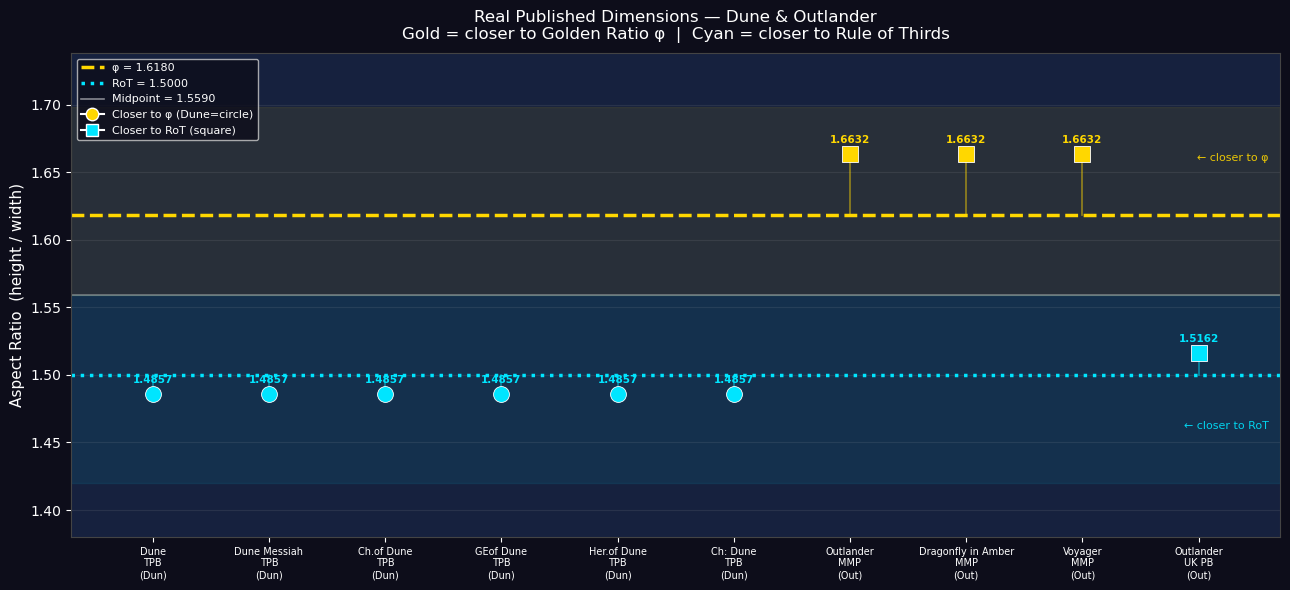

Saved: fig1_aspect_ratios.png


In [10]:
# ── Colour and style constants ───────────────────────────────────────────────
DARK  = '#0d0d1a'
MID   = '#16213e'
GOLD  = '#FFD700'
CYAN  = '#00e5ff'
RED   = '#ff6b6b'
GREEN = '#69ff47'
MIDPOINT = (PHI + ROT) / 2   # 1.5590 — equidistant from phi and RoT

# ── Figure 1: Aspect ratio strip chart ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(DARK)
ax.set_facecolor(MID)

# Reference lines
ax.axhline(PHI,      color=GOLD,  lw=2.5, linestyle='--', zorder=2,
           label=f'Golden Ratio  φ = {PHI:.4f}')
ax.axhline(ROT,      color=CYAN,  lw=2.5, linestyle=':',  zorder=2,
           label=f'Rule of Thirds  = {ROT:.4f}')
ax.axhline(MIDPOINT, color='white', lw=1.2, linestyle='-', alpha=0.35, zorder=2,
           label=f'Midpoint = {MIDPOINT:.4f}')

# Shade zone: closer to phi (above midpoint)
ax.axhspan(MIDPOINT, PHI + 0.08, alpha=0.08, color=GOLD)
# Shade zone: closer to RoT (below midpoint)
ax.axhspan(ROT - 0.08, MIDPOINT, alpha=0.08, color=CYAN)

# Plot each edition
markers  = {'Dune': 'o', 'Outlander': 's'}
x_labels = []

for i, (_, row) in enumerate(df.iterrows()):
    col    = GOLD if row.closer_to == 'Golden Ratio φ' else CYAN
    marker = markers[row.series]
    ax.scatter(i, row.aspect_ratio, color=col, marker=marker,
               s=130, zorder=5, edgecolors='white', linewidths=0.6)
    # Vertical line from point to nearest reference
    nearest = PHI if row.closer_to == 'Golden Ratio φ' else ROT
    ax.plot([i, i], [row.aspect_ratio, nearest],
            color=col, lw=1.2, alpha=0.5, zorder=3)
    # Label
    short = row.title.replace('Chapterhouse: ', 'Ch: ')\
                     .replace('Children of ', 'Ch.of ')\
                     .replace('God Emperor of ', 'GEof ')\
                     .replace('Heretics of ', 'Her.of ')\
                     .replace('A Breath of Snow and Ashes', 'Breath...')\
                     .replace('Written in My Own Heart\'s Blood', 'WIMOHB')\
                     .replace('Go Tell the Bees That I Am Gone', 'GTB...')
    fmt_short = row.format.replace('Mass Market Paperback','MMP')\
                          .replace('Trade Paperback','TPB')\
                          .replace('UK Paperback','UK PB')
    x_labels.append(f"{short}\n{fmt_short}\n({row.series[:3]})")

    # Annotate aspect ratio value
    ax.text(i, row.aspect_ratio + 0.007, f'{row.aspect_ratio:.4f}',
            ha='center', va='bottom', color=col, fontsize=7.5, fontweight='bold')

ax.set_xticks(range(len(df)))
ax.set_xticklabels(x_labels, color='white', fontsize=7, rotation=0)
ax.set_ylabel('Aspect Ratio  (height / width)', color='white', fontsize=11)
ax.set_ylim(ROT - 0.12, PHI + 0.12)
ax.set_xlim(-0.7, len(df) - 0.3)

# Zone labels
ax.text(len(df)-0.4, PHI + 0.04,  '← closer to φ',
        color=GOLD,  fontsize=8, ha='right', alpha=0.9)
ax.text(len(df)-0.4, ROT - 0.04,  '← closer to RoT',
        color=CYAN, fontsize=8, ha='right', alpha=0.9)

# Legend
legend_elements = [
    Line2D([0],[0], color=GOLD, lw=2.5, linestyle='--', label=f'φ = {PHI:.4f}'),
    Line2D([0],[0], color=CYAN, lw=2.5, linestyle=':',  label=f'RoT = {ROT:.4f}'),
    Line2D([0],[0], color='white', lw=1.2, alpha=0.5,   label=f'Midpoint = {MIDPOINT:.4f}'),
    Line2D([0],[0], marker='o', color='w', mfc=GOLD, ms=9, label='Closer to φ (Dune=circle)'),
    Line2D([0],[0], marker='s', color='w', mfc=CYAN, ms=9, label='Closer to RoT (square)'),
]
ax.legend(handles=legend_elements, facecolor=DARK, labelcolor='white',
          fontsize=8, loc='upper left')

ax.tick_params(colors='white')
ax.grid(True, alpha=0.12, axis='y')
for sp in ax.spines.values(): sp.set_edgecolor('#444')

ax.set_title(
    'Real Published Dimensions — Dune & Outlander\n'
    'Gold = closer to Golden Ratio φ  |  Cyan = closer to Rule of Thirds',
    color='white', fontsize=12, pad=10
)
plt.tight_layout()
plt.savefig('fig1_aspect_ratios.png', dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print('Saved: fig1_aspect_ratios.png')

Once again we see visually that real publishers do not strictly follow either compositional principle. From the graphic we see that The Ace Books Trade Paperback format (5.51 × 8.19 inches = 13.99 × 20.80 cm) has an aspect ratio of 1.4869, which is closer to the Rule of Thirds (1.5000) than to the Golden Ratio (1.6180). But the margin is small — only 0.13 away from RoT and 0.13 away from the midpoint.

The Dell Mass Market Paperback (4.15 × 6.9 inches) gives aspect ratio 1.6626 — this is actually closer to φ = 1.618 than to RoT = 1.5.
The UK Paperback (5.12 × 7.76 inches) gives 1.5156 — closer to Rule of Thirds. 

### 6. Abstract and Conclusion

   
The key mathematical observation is the difference in *division ratios*:

$$\text{Golden division: } \frac{1}{\varphi} \approx 0.618 \qquad \text{Thirds division: } \frac{2}{3} \approx 0.667$$

The discrepancy of about $0.049$ (5% of the canvas width) is small but visually perceptible, especially in layouts where precision matters.

The Golden Ratio grid has a richer algebraic structure:
- It is self-similar: subdividing the canvas with the golden ratio produces nested golden rectangles.
- It generates a logarithmic spiral, which appears throughout nature (nautilus shells, galaxy arms, hurricane eyes).
- The Fibonacci sequence is a discrete integer approximation to the continuous ratio.

    Practical Design Trade-offs

| Criterion | Golden Ratio | Rule of Thirds |
|---|---|---|
| Mathematical richness | Very high (spiral, self-similarity, irrationality) | Low (simple 1/3 fraction) |
| Precision in application | Requires tools or computation | Can be approximated by eye |
| Historical pedigree | Ancient (Euclid, Vitruvius, Renaissance art) | Modern (19th-century art instruction) |
| Applicable to text typography | Yes (text blocks, margin proportions) | Partially |
| Scientific evidence for superiority | Contested — some studies support, many do not | Contested |
| Best use case | Logo design, classical book typography, fine art | Photography, web design, film composition |

Limitations of this Study

1. Elements are modelled as **points** (centroids), ignoring their spatial extent.
2. No **user perception study** was conducted — we cannot claim that one system looks "better" to human observers.
3. Limitation of the database


